### Scenario 1: Montúfar (2014) Example with Hypercubes

This notebook compares the various sampling methods on the example from Montúfar (2014), where they construct a network whose linear regions are a grid of hypercubes.

#### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import scipy.stats.qmc as qmc

#### Functions to generate/load point sets:

In [186]:
def iid_uniform_sample(num_points,dimensions,runs,lower_bounds, upper_bounds, seed):
    """Generates several iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs,num_points,dimensions) representing all the points across all the samples
    """

    rng = np.random.default_rng(seed)
    
    # Generate points in [0,1)^d
    points = rng.uniform(size=(runs,num_points,dimensions))
    
    # Map points to desired rectangular region
    points = lower_bounds + (upper_bounds - lower_bounds)*points

    # Map to torch tensor
    points = torch.tensor(points)
    
    return points

In [77]:
def halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed):
    """Generates several halton samples of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs, num_points, dimensions)
    """

    points = np.empty((runs,num_points,dimensions))
    
    # You can use the same rng for all the runs because the state will evolve every time you call qmc.Halton() again
    rng = np.random.default_rng(seed)
    for i in range(runs):
        sampler = qmc.Halton(d=dimensions,scramble=True,seed=rng)
        points[i,:,:] = sampler.random(num_points)

    # Convert to torch tensor for neural network processing
    points = torch.tensor(points)
    
    return points

In [299]:
def sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds):
    """Generates several sobol samples of points with different sample sizes
    Args:
        sample_sizes: a list of sample sizes to use for the region counting
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        all_points: a list of 3D arrays of shape (runs, num_points, dimensions)
    """

    all_points = []

    for i in range(len(sample_sizes)):
        
        points = np.empty((runs,sample_sizes[i],dimensions))
        rng = np.random.default_rng(seed=i)
        
        for j in range(runs):
            
            sampler = qmc.Sobol(d=dimensions,scramble=True,seed=rng)
            points[j,:,:] = sampler.random(sample_sizes[i])

        # Convert to torch tensor so we can put through the neural network
        points = torch.tensor(points)
        
        all_points.append(points)

    return all_points

Test function for uniform sample:

In [29]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [30]:
print(points.shape)

torch.Size([100, 10000, 2])


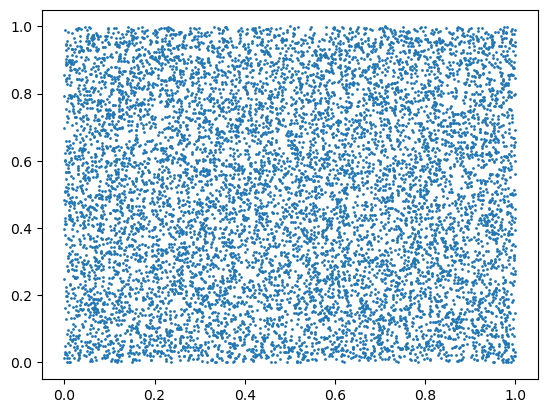

In [32]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Halton sample:

In [78]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [79]:
print(points.shape)

torch.Size([100, 10000, 2])


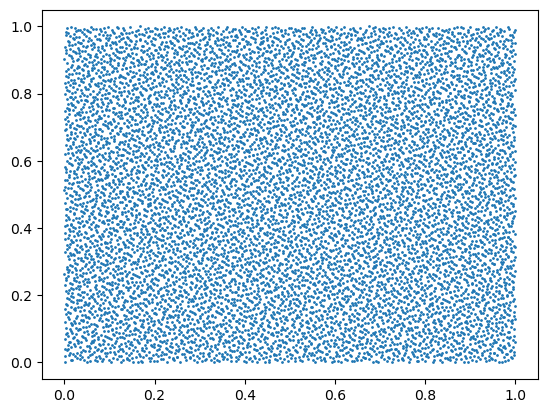

In [84]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Sobol sample:

In [285]:
sample_sizes = [2**6,2**7,2**8,2**9]
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

In [295]:
first_set = points[3]

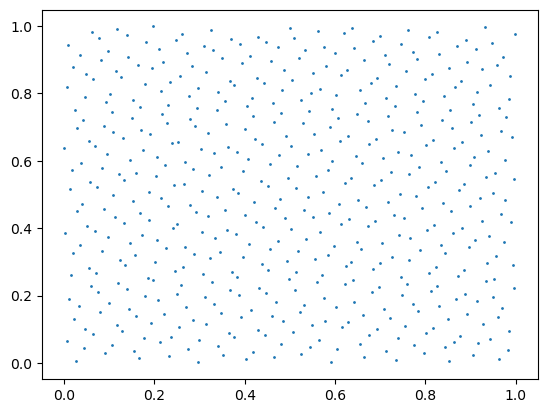

In [296]:
plt.scatter(first_set[5,:,0],first_set[5,:,1],s=1)

#### Code to set up MLP

In [2]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 3D array of inputs of shape (number of runs, number of points, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 3D array of shape: (number of runs, number of points, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after ReLU layers (>0 if on, =0 if off)
            if isinstance(layer,torch.nn.ReLU):
                # If we do not have the first layer, concatenate the activations along the last axis
                try:
                    activations = torch.cat((activations,x),axis=-1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x
        return activations

#### Code to count linear regions

Online region counting function which uses subsets of a larger sample (for Binomial Point Process/Halton Sequence):

In [182]:
def region_count_online(input_points,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        points: torch tensor of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    unique_counts = torch.zeros((input_points.shape[0],input_points.shape[1]))

    # Get array of activations with shape (number of runs, number of points, total number of neurons)
    activations = model(input_points)
    # For all the activations that are greater than 0, set the state to 1
    states = torch.zeros(activations.shape)
    states[activations>0] = 1
    states = states.to(torch.int64)
    
    # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
    cols = states.shape[-1]
    powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
    activation_patterns = (states * powers).sum(dim=-1)

    # COUNT NUMBER OF UNIQUE REGIONS

    # Sort the activation patterns and get corresponding indices (stable = True ensures the first occurance is put first)
    sorted_t, indices = torch.sort(activation_patterns, dim=1, stable=True)
    
    # Find the first occurance of each new activation pattern as a Boolean Mask
    is_first_sorted = torch.ones_like(activation_patterns, dtype=torch.bool)
    is_first_sorted[:, 1:] = sorted_t[:, 1:] != sorted_t[:, :-1]
    
    # Put the true and false values back in their original order
    is_first_chronological = torch.empty_like(is_first_sorted)
    is_first_chronological.scatter_(dim=1, index=indices, src=is_first_sorted)
    
    # Count the number of true values up to each column using cumulative sum function in torch
    unique_counts = is_first_chronological.int().cumsum(dim=1)

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = activation_patterns[is_first_chronological]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            samples_by_region[pattern] = input_points[activation_patterns==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

Offline region counting function which uses separate sample sizes (for Sobol Sequence/Gaussian Blue Noise)

In [184]:
def region_count_offline(input_points_list,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        input_points_list: list of torch tensors of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    runs = input_points_list[0].shape[0]
    unique_counts = torch.zeros((runs,len(input_points_list)))

    for i in range(len(input_points_list)):

        input_points = input_points_list[i]

        # Get array of activations with shape (number of runs, number of points, total number of neurons)
        activations = model(input_points)
        # For all the activations that are greater than 0, set the state to 1
        states = torch.zeros(activations.shape)
        states[activations>0] = 1
        states = states.to(torch.int64)
        
        # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
        cols = states.shape[-1]
        powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
        activation_patterns = (states * powers).sum(dim=-1)
    
        # COUNT NUMBER OF UNIQUE REGIONS
    
        sorted_t, _ = torch.sort(activation_patterns, dim=1)
        changes = sorted_t[:, 1:] != sorted_t[:, :-1]
        counts_sample_size = changes.sum(dim=1) + 1

        unique_counts[:,i] = counts_sample_size

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = activation_patterns[is_first_chronological]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            samples_by_region[pattern] = input_points[activation_patterns==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

#### Example Networks

a) Network: 
- $n_0 = 4$ dimensional input
- 1 hidden layer of $40$ neurons divided into $p=10$ neuron blocks by the weights
- Exact count of regions = $p^{n_0} = 10^4 = 10000$

1. Use uniformly distributed sample points

In [21]:
num_points = 1000000
dimensions = 4
runs = 100
neurons_per_hidden = [40]
custom_weights = [torch.tensor([[1,0,0,0] for i in range(10)] + [[0,1,0,0] for i in range(10)]+[[0,0,1,0] for i in range(10)]+[[0,0,0,1]
                              for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],4))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=10)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
uniform_sample = torch.tensor(rng.uniform(0,1,size=(runs, num_points, dimensions)))
start_time = time.time()
unique_counts, samples_by_region = region_count_2(uniform_sample,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

64.98533487319946


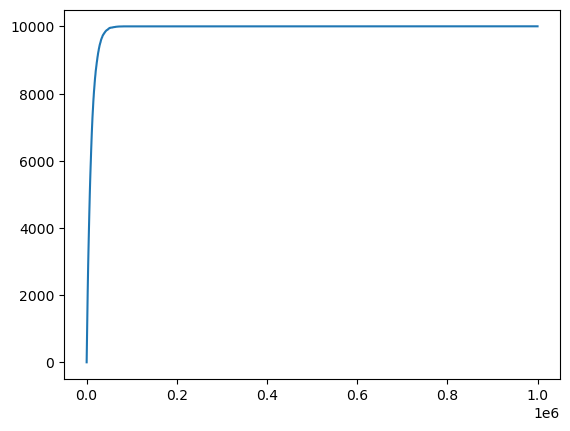

In [22]:
x = np.arange(1000000)
plt.plot(x,unique_counts[0,:1000000])

In [23]:
variances = torch.var(unique_counts.float(),axis=0)

Text(0, 0.5, 'Var($L_n$)')

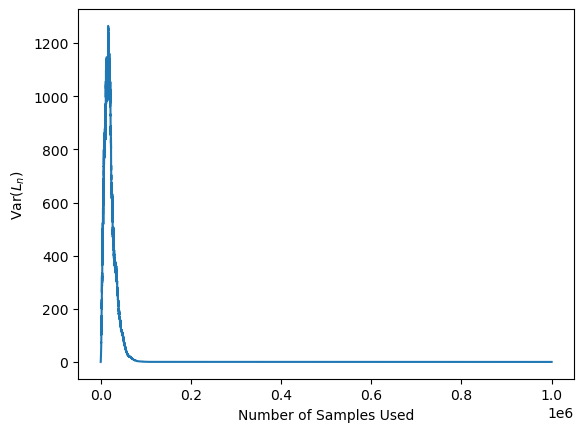

In [48]:
x = np.arange(1000000)
plt.plot(x,variances[:1000000])
plt.xlabel("Number of Samples Used")
plt.ylabel(r"Var($L_n$)")

2. Use Halton Sequence of points

In [25]:
# Generate 100 Halton Point Sets in 4 dimensions

runs = 100
num_points = 1000000
dimensions = 4

input_points = np.empty((runs,num_points,dimensions))

rng = np.random.default_rng(seed=10)
for i in range(runs):
    sampler = qmc.Halton(d=4,scramble=True,seed=rng)
    input_points[i,:,:] = sampler.random(1000000)

In [26]:
input_points = torch.tensor(input_points)

In [27]:
neurons_per_hidden = [40]
custom_weights = [torch.tensor([[1,0,0,0] for i in range(10)] + [[0,1,0,0] for i in range(10)]+[[0,0,1,0] for i in range(10)]+[[0,0,0,1]
                              for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],4))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
start_time = time.time()
halton_unique_counts, samples_by_region = region_count_2(input_points,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

61.892921686172485


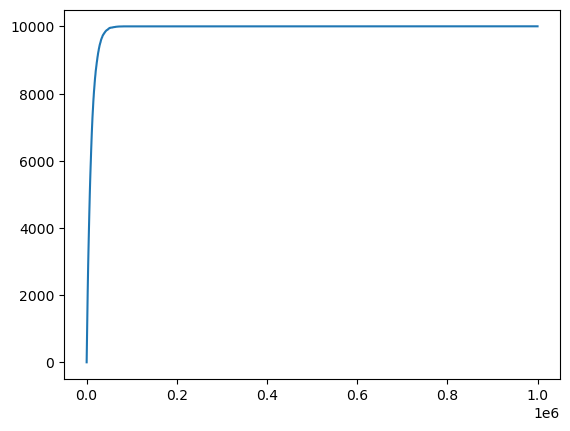

In [28]:
x = np.arange(1000000)
plt.plot(x,unique_counts[0,:])

In [38]:
halton_variances = torch.var(halton_unique_counts.float(),axis=0)

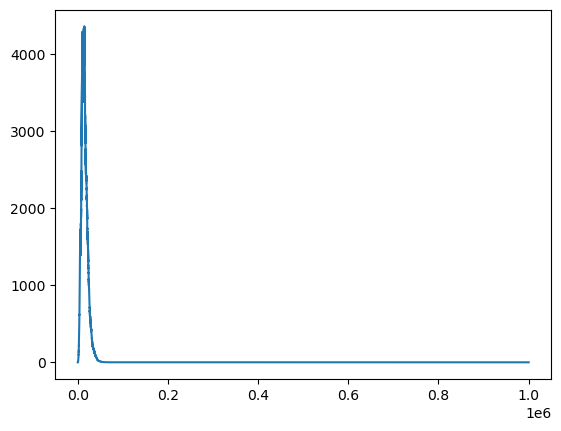

In [39]:
plt.plot(x,halton_variances)

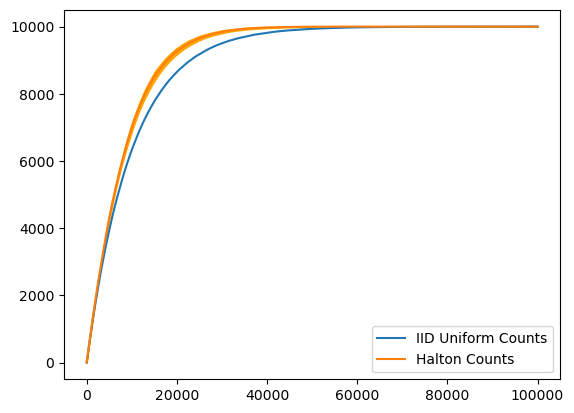

In [47]:
plt.plot(x[:100000],torch.mean(unique_counts[:,:100000].float(),axis=0),label="IID Uniform Counts")
plt.plot(x[:100000],torch.mean(halton_unique_counts[:,:100000].float(),axis=0),label="Halton Counts")
plt.fill_between(x[:100000],torch.mean(halton_unique_counts[:,:100000].float(),axis=0)-2*torch.sqrt(halton_variances[:100000]),torch.mean(halton_unique_counts[:,:100000].float(),axis=0)+2*torch.sqrt(halton_variances[:100000]),color="orange")
plt.legend()

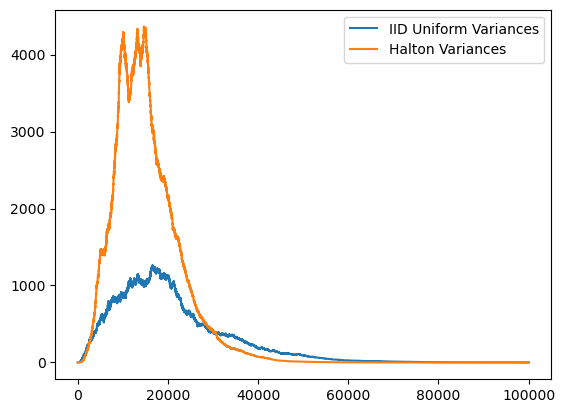

In [40]:
plt.plot(x[:100000],variances[:100000],label="IID Uniform Variances")
plt.plot(x[:100000],halton_variances[:100000],label="Halton Variances")
plt.legend()

b) Network: 
- $n_0 = 3$ dimensional input
- 30 hidden units partitioned into 3 subsets of size $p=10$
- Exact number of regions = $p^{n_0} = 10^3=1000$

In [50]:
num_points = 1000000
dimensions = 3
runs = 100
neurons_per_hidden = [30]
custom_weights = [torch.tensor([[1,0,0] for i in range(10)] + [[0,1,0] for i in range(10)]+[[0,0,1] for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],3))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=10)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
uniform_sample = torch.tensor(rng.uniform(0,1,size=(runs, num_points, dimensions)))
start_time = time.time()
unique_counts, samples_by_region = region_count_2(uniform_sample,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

31.668053150177002


In [56]:
# Generate 100 Halton Point Sets in 4 dimensions

runs = 100
num_points = 1000000
dimensions = 3

input_points = np.empty((runs,num_points,dimensions))

rng = np.random.default_rng(seed=10)
for i in range(runs):
    sampler = qmc.Halton(d=3,scramble=True,seed=rng)
    input_points[i,:,:] = sampler.random(1000000)

In [59]:
input_points = torch.tensor(input_points)

In [62]:
neurons_per_hidden = [30]
custom_weights = [torch.tensor([[1,0,0] for i in range(10)] + [[0,1,0] for i in range(10)]+[[0,0,1] for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],3))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
start_time = time.time()
halton_unique_counts, samples_by_region = region_count_2(input_points,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

32.785593032836914


In [69]:
variances = torch.var(unique_counts[:,:10000].float(),axis=0)
halton_variances = torch.var(halton_unique_counts[:,:10000].float(),axis=0)

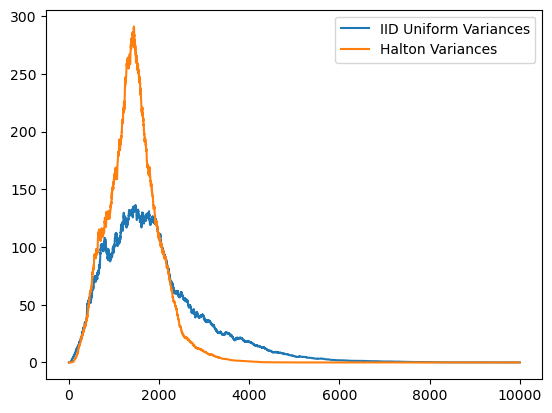

In [70]:
plt.plot(x[:10000],variances[:10000],label="IID Uniform Variances")
plt.plot(x[:10000],halton_variances[:10000],label="Halton Variances")
plt.legend()

In [85]:
mean = torch.mean(unique_counts[:,:10000].float(),axis=0)
halton_mean = torch.mean(halton_unique_counts[:,:10000].float(),axis=0)

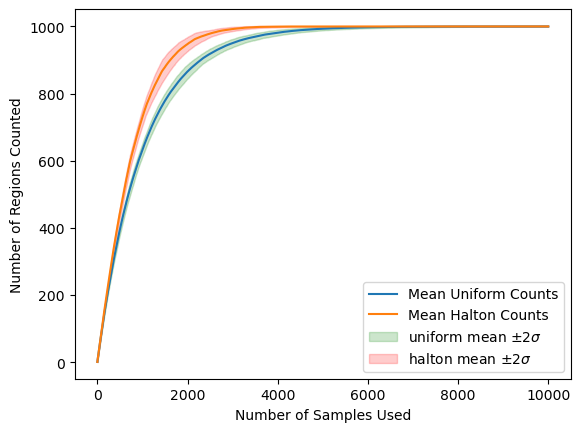

In [93]:
x = np.arange(1000000)
plt.plot(x[:10000],torch.mean(unique_counts[:,:10000].float(),axis=0),label="Mean Uniform Counts")
plt.plot(x[:10000],torch.mean(halton_unique_counts[:,:10000].float(),axis=0),label="Mean Halton Counts")
plt.fill_between(x[:10000],mean-2*torch.sqrt(variances[:10000]),mean+2*torch.sqrt(variances[:10000]),color="green",alpha=0.2,label=r"uniform mean $\pm 2 \sigma$")
plt.fill_between(x[:10000],halton_mean-2*torch.sqrt(halton_variances[:10000]),halton_mean+2*torch.sqrt(halton_variances[:10000]),color="red",alpha=0.2,label=r"halton mean $\pm 2 \sigma$")
plt.xlabel("Number of Samples Used")
plt.ylabel("Number of Regions Counted")
plt.legend()

c) Network:

- $n_0 = 2$ dimensional input
- 1 hidden layer of 16 neurons divided into subsets of size $p=8$ by the weights
- Exact number of regions is $p^{n_0}=8^2=16$

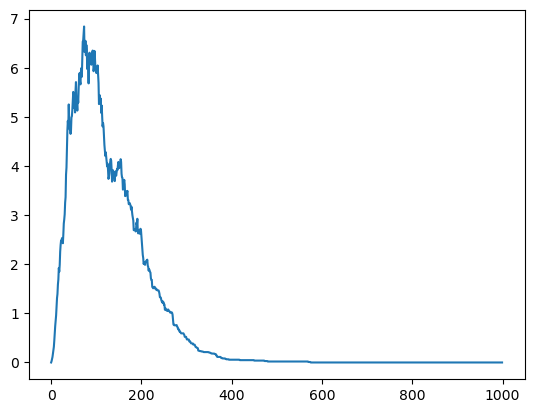

In [180]:
plt.plot(x,np.var(unique_counts.numpy(),axis=0))

Plot regions:

Text(0, 0.5, '$x_{2}$')

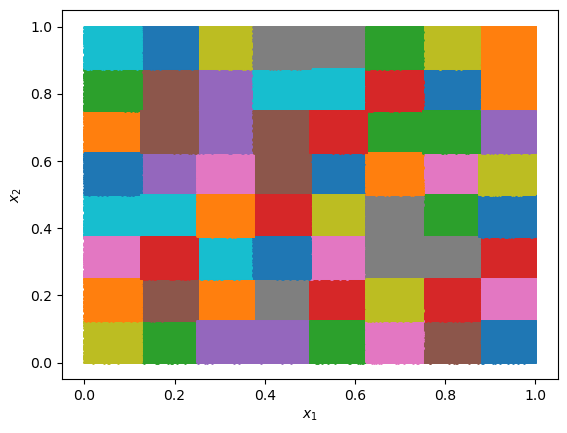

In [53]:
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

Estimate volumes of regions:

In [54]:
volumes = []
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    volume_fraction = len(samples)/1000000
    volumes.append(volume_fraction)

(array([ 2., 10., 10., 15., 12.,  2.,  5.,  4.,  2.,  2.]),
 array([0.015403 , 0.0154582, 0.0155134, 0.0155686, 0.0156238, 0.015679 ,
        0.0157342, 0.0157894, 0.0158446, 0.0158998, 0.015955 ]),
 <BarContainer object of 10 artists>)

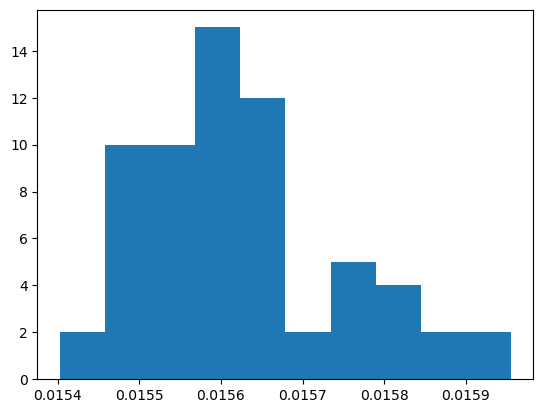

In [57]:
plt.hist(volumes,bins=10)

#### Formal Experiment

In [185]:
def experiment_2(sample_points,hidden_neurons,dimensions,runs=100,mode="online"):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    # Set the network biases using p and dimension
    custom_biases = [torch.tensor(np.tile([-i/p for i in range(p)], dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=False)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=False)

    return unique_counts

**EXPERIMENT 2A:**
- neurons per hidden $= 40$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- $p = 20,13,10,8,6,5,5,4,4$
- regions $= 400,2197,10000,32768,46656,78125,390625,262144,1048576$

In [102]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 40

iid_counts = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts[dimensions-2,:,:] = unique_counts

In [110]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 40

halton_counts = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    halton_counts[dimensions-2,:,:] = unique_counts

Calculate summary statistics for Uniform and Halton and compare:

In [132]:
uniform_mean = np.mean(iid_counts,axis=1)
halton_mean = np.mean(halton_counts,axis=1)
uniform_variances = np.var(iid_counts,axis=1)
halton_variances = np.var(halton_counts,axis=1)

1. Maximum Variance against True Number of Regions for uniform

In [121]:
maximum_uniform_variances = np.max(uniform_variances,axis=1)[:-1]

In [176]:
maximum_halton_variances = np.max(halton_variances,axis=1)[:-1]

In [122]:
maximum_region_count = [400,2197,10000,32768,46656,78125,390625,262144,1048576]

Text(0, 0.5, '$\\log(\\text{Maximum Variance})$')

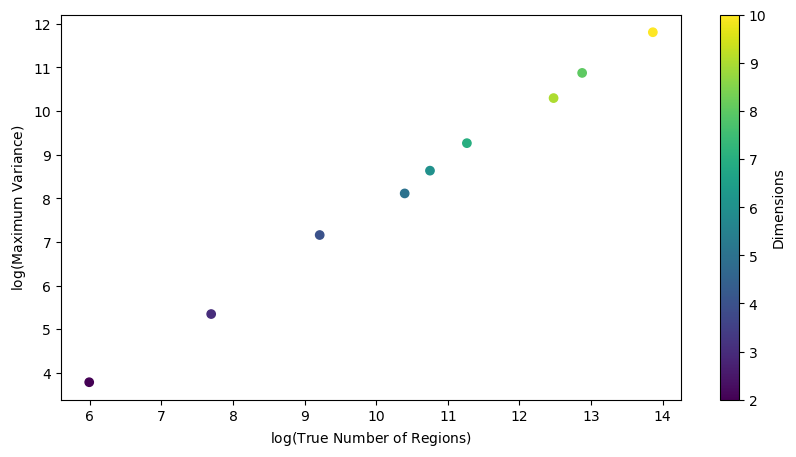

In [175]:
plt.figure(figsize=(10,5))
plt.scatter(np.log(maximum_region_count),np.log(maximum_uniform_variances),c=all_dimensions,cmap="viridis")
plt.colorbar(label="Dimensions")
plt.xlabel(r"$\log(\text{True Number of Regions})$")
plt.ylabel(r"$\log(\text{Maximum Variance})$")

There is very likely a proportional relationship between the maximum variance and the true number of regions -> can we prove this?

In [329]:
def var(x,n):
    var = (x-1)**n/x**(n-1) + (x-1)*(x-2)**n/x**(n-1) - (x-1)**(2*n)/x**(2*n-2)
    return var

2. Saturation point for Uniform and Halton

In [159]:
uniform_saturations = []
for i in range(len(all_dimensions)):
    try:
        first_time = np.where(uniform_mean[i,:] == maximum_region_count[i])[0][0]
        uniform_saturations.append(first_time)
    # Saturation point has not been reached
    except:
        uniform_saturations.append("N/A")


In [160]:
halton_saturations = []
for i in range(len(all_dimensions)):
    try:
        first_time = np.where(halton_mean[i,:] == maximum_region_count[i])[0][0]
        halton_saturations.append(first_time)
    # Saturation point has not been reached
    except:
        halton_saturations.append("N/A")

In [162]:
print("Uniform Saturation Points: ", uniform_saturations)
print("Halton Saturation Points: ", halton_saturations)

Uniform Saturation Points:  [5569, 27688, 146404, 463607, 804615, 'N/A', 'N/A', 'N/A', 'N/A']
Halton Saturation Points:  [1724, 14089, 85954, 331911, 582170, 'N/A', 'N/A', 'N/A', 'N/A']


Halton points consistently converge faster in number of linear regions than uniform points for this example

3. Maximum variance in terms of number of dimensions:

Text(0, 0.5, 'Maximum Variance')

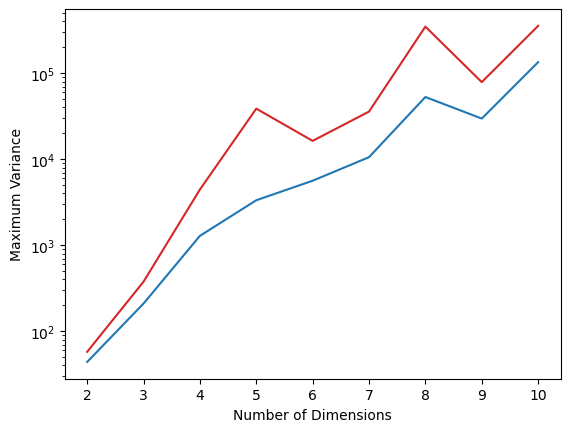

In [181]:
plt.semilogy(all_dimensions,maximum_uniform_variances,color="tab:blue",label="Uniform Points")
plt.semilogy(all_dimensions,maximum_halton_variances,color="tab:red",label="Halton Points")
plt.xlabel("Number of Dimensions")
plt.ylabel("Maximum Variance")

So for this example, using Halton points actually increases variance but this is offset by a significant reduction in bias, meaning the rate of convergence for the estimator using Halton Points is higher in this case.

Compare uniform sampling in online and offline cases:

In [237]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
num_points = 1000000
dimensions = 5
runs = 100
hidden_neurons = 40

iid_counts_offline = np.empty((runs,len(sample_sizes)))

input_points = []
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

for i in range(len(sample_sizes)):

    point_set = iid_uniform_sample(sample_sizes[i],dimensions,runs,lower_bounds,upper_bounds,seed=i)
    input_points.append(point_set)

# Count linear region susing those point sets and assign to the appropriate part of iid_counts
unique_counts = experiment_2(input_points,hidden_neurons,dimensions,runs,mode="offline")
unique_counts = unique_counts.detach().numpy()

In [238]:
mean_counts = np.mean(unique_counts,axis=0)

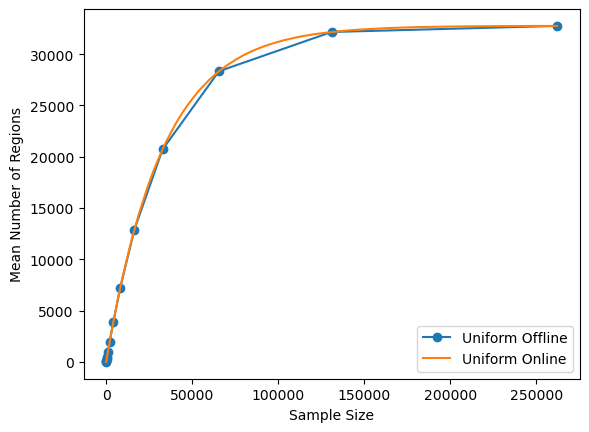

In [239]:
plt.plot(sample_sizes[:14],mean_counts[:14],marker="o",label="Uniform Offline")
x = np.arange(2**18)
plt.plot(x,uniform_mean[3][:2**18],label="Uniform Online")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

In [240]:
variance_counts = np.var(unique_counts,axis=0)

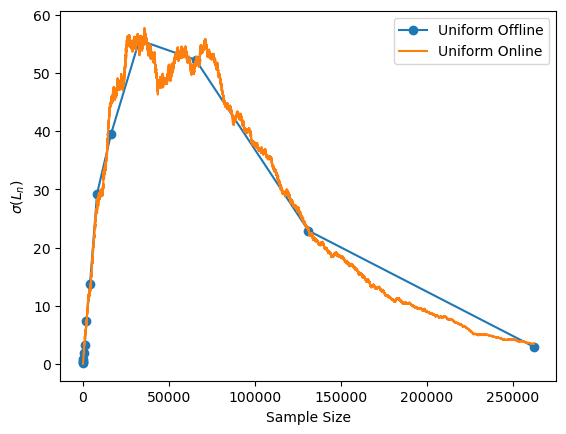

In [241]:
plt.plot(sample_sizes[:14],np.sqrt(variance_counts)[:14],marker="o",label="Uniform Offline")
plt.plot(x,np.sqrt(uniform_variances[3][:2**18]),label="Uniform Online")
plt.xlabel("Sample Size")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

Compare Halton Sampling in online and offline cases:

In [242]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
num_points = 1000000
dimensions = 5
runs = 100
hidden_neurons = 40

iid_counts_offline = np.empty((runs,len(sample_sizes)))

input_points = []
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

for i in range(len(sample_sizes)):

    point_set = halton_sample(sample_sizes[i],dimensions,runs,lower_bounds,upper_bounds,seed=i)
    input_points.append(point_set)

# Count linear region susing those point sets and assign to the appropriate part of iid_counts
unique_counts = experiment_2(input_points,hidden_neurons,dimensions,runs,mode="offline")
unique_counts = unique_counts.detach().numpy()

In [243]:
mean_counts = np.mean(unique_counts,axis=0)

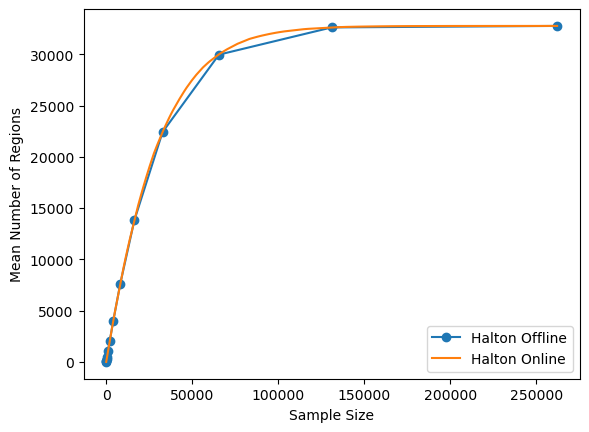

In [247]:
plt.plot(sample_sizes[:14],mean_counts[:14],marker="o",label="Halton Offline")
x = np.arange(2**18)
plt.plot(x,halton_mean[3][:2**18],label="Halton Online")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

In [248]:
variance_counts = np.var(unique_counts,axis=0)

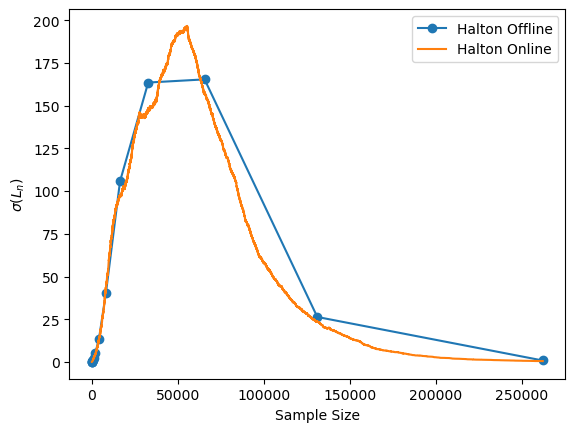

In [252]:
plt.plot(sample_sizes[:14],np.sqrt(variance_counts)[:14],marker="o",label="Halton Offline")
plt.plot(x,np.sqrt(halton_variances[3][:2**18]),label="Halton Online")
plt.xlabel("Sample Size")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

Sobol sequences:

In [302]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
runs = 100
hidden_neurons = 40

sobol_counts = np.empty((max(all_dimensions),runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts[dimensions-2,:,:] = unique_counts

In [303]:
sobol_mean = np.mean(sobol_counts,axis=1)
sobol_variances = np.var(sobol_counts,axis=1)

Compare convergence rate and variance to uniform:

In [314]:
x = np.arange(2**19)

In [396]:
uniform_powers_mean = uniform_mean[:,sample_sizes]
uniform_powers_variances = uniform_variances[:,sample_sizes]

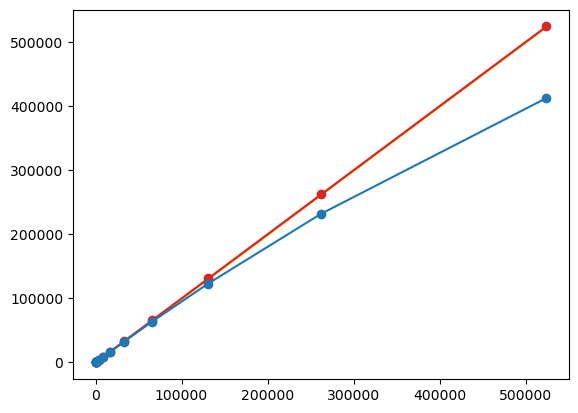

In [399]:
plt.plot(sample_sizes,sobol_mean[8,:],marker="o",color="tab:red")
plt.fill_between(sample_sizes,sobol_mean[8,:]-2*np.sqrt(sobol_variances[8,:]),sobol_mean[8,:]+2*np.sqrt(sobol_variances[8,:]),color="orange",alpha=1)
plt.plot(sample_sizes,uniform_powers_mean[8,:],marker="o")
plt.plot(sample_sizes,uniform_powers_mean[8,:]-2*np.sqrt(uniform_powers_variances[8,:]),uniform_powers_mean[8,:]+2*np.sqrt(uniform_powers_variances[8,:]),
         color="green",alpha=0)                                                        

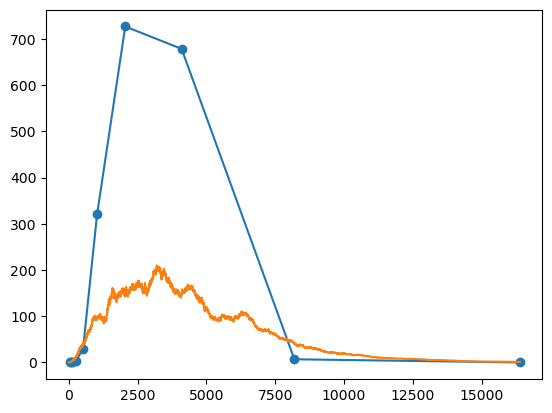

In [354]:
plt.plot(sample_sizes[:10],sobol_variances[1,:10],marker="o")
plt.plot(x[:2**14+1],uniform_variances[1,:2**14+1])